In [ ]:
# Step 1: Load the Dataset
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [ ]:
# Load dataset
file_path = "/content/Quality of Service 5G.csv"
df = pd.read_csv(file_path)

In [ ]:
# Convert numeric columns to proper formats
df["Signal_Strength"] = df["Signal_Strength"].str.replace(" dBm", "").astype(float)
df["Latency"] = df["Latency"].str.replace(" ms", "").astype(float)
df["Required_Bandwidth"] = df["Required_Bandwidth"].str.replace(" Mbps", "").str.replace(" Kbps", "").astype(float)
df["Allocated_Bandwidth"] = df["Allocated_Bandwidth"].str.replace(" Mbps", "").str.replace(" Kbps", "").astype(float)
df["Resource_Allocation"] = df["Resource_Allocation"].str.replace("%", "").astype(float)

In [ ]:
# Encode categorical column (Application_Type)
df["Application_Type"] = df["Application_Type"].astype("category").cat.codes

print("✅ Dataset loaded and preprocessed successfully!")

✅ Dataset loaded and preprocessed successfully!


In [ ]:
# Step 2: Compute Shannon Entropy

def shannon_entropy(data):
    """Computes Shannon entropy for a given feature."""
    value_counts = data.value_counts(normalize=True)  # Compute probabilities
    return stats.entropy(value_counts)  # Compute entropy

In [ ]:
# Compute entropy for all numerical columns
entropy_scores = df.apply(shannon_entropy)

# Step 4: Feature Selection (Select High-Entropy Features)
selected_features = entropy_scores[entropy_scores > entropy_scores.median()].index.tolist()

# Display entropy values
print("🔹 Entropy Scores for Each Feature:")
print(entropy_scores)

🔹 Entropy Scores for Each Feature:
Timestamp              1.942700
User_ID                5.991465
Application_Type       2.176683
Signal_Strength        4.328753
Latency                4.061066
Required_Bandwidth     4.803795
Allocated_Bandwidth    4.867689
Resource_Allocation    1.730246
dtype: float64


In [ ]:


# Print selected features
print("\n🚀 Selected High-Entropy Features for Anomaly Detection:")
print(selected_features)



🚀 Selected High-Entropy Features for Anomaly Detection:
['User_ID', 'Signal_Strength', 'Required_Bandwidth', 'Allocated_Bandwidth']


In [ ]:
# Step 5: Remove 'User_ID' Column (If Exists)
if "User_ID" in df.columns:
    df = df.drop(columns=["User_ID"])
    print("✅ Step 5: 'User_ID' Column Removed!")


✅ Step 5: 'User_ID' Column Removed!


In [ ]:
# Ensure 'User_ID' is not in selected_features
selected_features = [feature for feature in selected_features if feature in df.columns]

print("\n🚀 Step 6: Final Selected Features for Clustering:")
print(selected_features)


🚀 Step 6: Final Selected Features for Clustering:
['Signal_Strength', 'Required_Bandwidth', 'Allocated_Bandwidth']


In [ ]:
#Step 6: Normalize Selected High-Entropy Features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[selected_features])

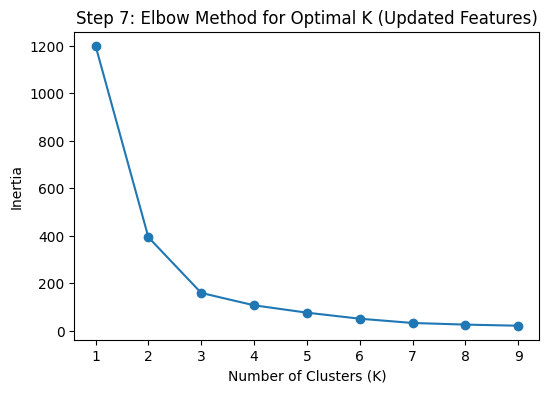

In [ ]:
# Step 7: Find Optimal Number of Clusters Using Elbow Method
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(6, 4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Step 7: Elbow Method for Optimal K (Updated Features)')
plt.show()

In [ ]:
# Test K=3 and K=4 for Silhouette Score
k_values = [3, 4]
silhouette_scores = {}

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df_scaled)
    silhouette_avg = silhouette_score(df_scaled, cluster_labels)
    silhouette_scores[k] = silhouette_avg
    print(f"🔹 Silhouette Score for K={k}: {silhouette_avg}")

# Select the best K (higher Silhouette Score is better)
optimal_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\n✅ Optimal number of clusters selected: K={optimal_k}")

🔹 Silhouette Score for K=3: 0.5802655757781772
🔹 Silhouette Score for K=4: 0.5400858912870826

✅ Optimal number of clusters selected: K=3


In [ ]:
# Step 9: Apply K-Means Clustering with Optimal K and Save the Results
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(df_scaled)

# Save the clustered dataset
file_path_output = "/content/Clustered_5G_QoS_Data.csv"
df.to_csv(file_path_output, index=False)

In [ ]:
file_path = "/content/Clustered_5G_QoS_Data.csv"
df_clustered = pd.read_csv(file_path)

In [ ]:
# Step 2: Separate Data into Different Cluster Files
for cluster_num in df_clustered["Cluster"].unique():
    df_cluster = df_clustered[df_clustered["Cluster"] == cluster_num]
    file_name = f"/content/Cluster_{cluster_num}_5G_QoS.csv"
    df_cluster.to_csv(file_name, index=False)
    print(f"✅ Saved Cluster {cluster_num} Data: {file_name}")
    print("\n✅ Cluster separation completed! Each cluster has been saved as a separate file.")


✅ Saved Cluster 0 Data: /content/Cluster_0_5G_QoS.csv

✅ Cluster separation completed! Each cluster has been saved as a separate file.
✅ Saved Cluster 2 Data: /content/Cluster_2_5G_QoS.csv

✅ Cluster separation completed! Each cluster has been saved as a separate file.
✅ Saved Cluster 1 Data: /content/Cluster_1_5G_QoS.csv

✅ Cluster separation completed! Each cluster has been saved as a separate file.


<ipython-input-27-1247d9695359>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_clustered["Cluster"], y=df_clustered["Signal_Strength"], palette="viridis")


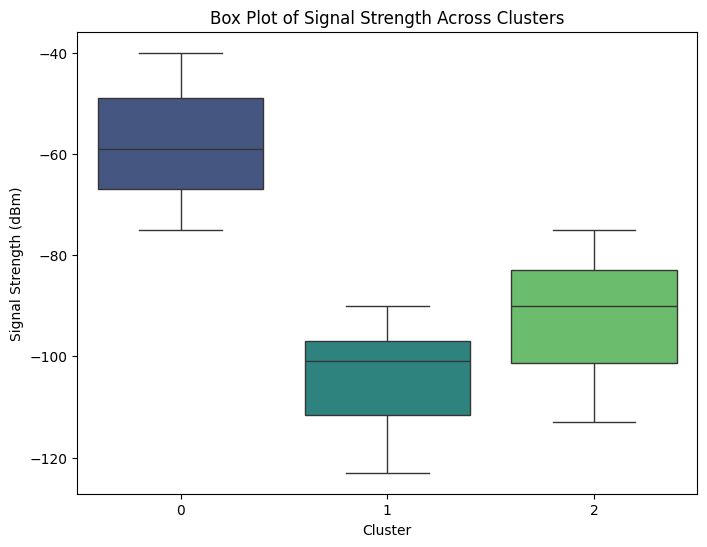

<ipython-input-27-1247d9695359>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_clustered["Cluster"], y=df_clustered["Required_Bandwidth"], palette="viridis")


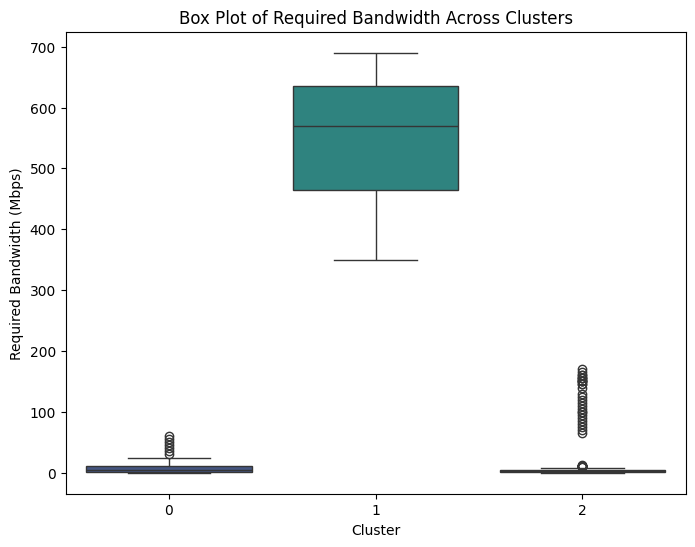

<ipython-input-27-1247d9695359>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_clustered["Cluster"], y=df_clustered["Allocated_Bandwidth"], palette="viridis")


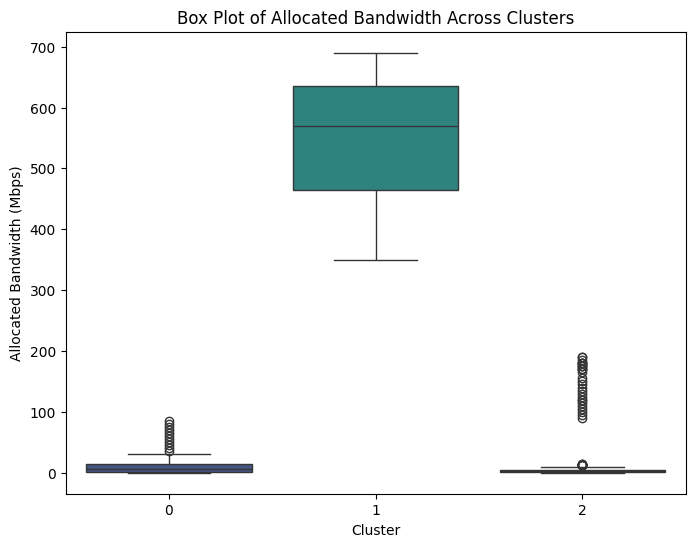

In [ ]:
import seaborn as sns
#Step 1: Load the Clustered Dataset
file_path = "/content/Clustered_5G_QoS_Data.csv"
df_clustered = pd.read_csv(file_path)

# Step 2: Box Plot for Signal Strength Distribution Across Clusters
plt.figure(figsize=(8,6))
sns.boxplot(x=df_clustered["Cluster"], y=df_clustered["Signal_Strength"], palette="viridis")
plt.xlabel("Cluster")
plt.ylabel("Signal Strength (dBm)")
plt.title("Box Plot of Signal Strength Across Clusters")
plt.show()

# Step 3: Box Plot for Required Bandwidth Across Clusters
plt.figure(figsize=(8,6))
sns.boxplot(x=df_clustered["Cluster"], y=df_clustered["Required_Bandwidth"], palette="viridis")
plt.xlabel("Cluster")
plt.ylabel("Required Bandwidth (Mbps)")
plt.title("Box Plot of Required Bandwidth Across Clusters")
plt.show()

# Step 4: Box Plot for Allocated Bandwidth Across Clusters
plt.figure(figsize=(8,6))
sns.boxplot(x=df_clustered["Cluster"], y=df_clustered["Allocated_Bandwidth"], palette="viridis")
plt.xlabel("Cluster")
plt.ylabel("Allocated Bandwidth (Mbps)")
plt.title("Box Plot of Allocated Bandwidth Across Clusters")
plt.show()

In [ ]:
# Step 1: Install Required Libraries (Run this if TensorFlow is not installed)
# !pip install tensorflow pandas scikit-learn numpy

# Step 2: Import Required Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Step 3: Load the Clustered Dataset
file_path = "/content/Clustered_5G_QoS_Data.csv"  # Update with the correct file path
df = pd.read_csv(file_path)

# Step 4: Train Autoencoder on Cluster 1 (Normal Users)
df_cluster_1 = df[df["Cluster"] == 1].copy()  # Use .copy() to avoid modifying the original DataFrame

# Step 5: Select Features for Training
features = ["Signal_Strength", "Required_Bandwidth", "Allocated_Bandwidth"]
train_data = df_cluster_1[features].values

# Step 6: Normalize the Training Data
scaler = StandardScaler()
train_data_scaled = scaler.fit_transform(train_data)

# Step 7: Define Autoencoder Model
input_dim = train_data_scaled.shape[1]  # Number of features
encoding_dim = 3  # Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# Create Autoencoder Model
autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Step 8: Train Autoencoder on Cluster 1 Data
autoencoder.fit(train_data_scaled, train_data_scaled, epochs=50, batch_size=16, shuffle=True, verbose=1)

# Step 9: Test Autoencoder on the Entire Dataset (Clusters 0, 1, and 2)
df_test = df.copy()  # Ensure we don't modify the original DataFrame
test_data = df_test[features].values

# Normalize the Test Data
test_data_scaled = scaler.transform(test_data)

# Compute Reconstruction Error
reconstructed_data = autoencoder.predict(test_data_scaled)
reconstruction_errors = np.mean(np.abs(reconstructed_data - test_data_scaled), axis=1)

# Step 10: Add Anomaly Scores to the DataFrame using .loc to avoid SettingWithCopyWarning
df_test.loc[:, "Reconstruction_Error"] = reconstruction_errors

# Step 11: Define Anomaly Threshold (60th Percentile for Sensitivity)
threshold = np.percentile(reconstruction_errors, 25)

# Step 12: Label Anomalies (1 = Abnormal, 0 = Normal) using .loc
df_test.loc[:, "Anomaly"] = (df_test["Reconstruction_Error"] > threshold).astype(int)

# Step 13: Save the Results
file_output = "/content/Autoencoder_Anomaly_Detection_Cluster_1.csv"
df_test.to_csv(file_output, index=False)

# Step 14: Display Results
print(f"✅ Autoencoder Training and Testing Completed! Results saved to {file_output}")




Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.3025 
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.4912
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.1190
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.2254
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.2095
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.2419
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.1775
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.1945
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9723
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.3335
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.2042
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.1392
Epoch 13/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.0397
Epoch 14/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.9718
Epoch 15/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.2500
Epoch 16/50
3/3 ━━━━━━━━━━━━━━━━━

In [ ]:
import pandas as pd

# Step 1: Load the Autoencoder Anomaly Detection Results
file_path = "/content/Autoencoder_Anomaly_Detection_Cluster_1.csv"  # Update path if needed
df_anomaly = pd.read_csv(file_path)

# Step 2: Separate Data into Three Different Files Based on Cluster Labels
for cluster_num in df_anomaly["Cluster"].unique():
    df_cluster = df_anomaly[df_anomaly["Cluster"] == cluster_num].copy()
    file_name = f"Anomaly_Cluster_{cluster_num}.csv"
    df_cluster.to_csv(file_name, index=False)
    print(f"✅ Saved Cluster {cluster_num} Data with Anomaly Column: {file_name}")

print("\n✅ Cluster separation completed! Each cluster file includes the anomaly column.")


✅ Saved Cluster 0 Data with Anomaly Column: Anomaly_Cluster_0.csv
✅ Saved Cluster 2 Data with Anomaly Column: Anomaly_Cluster_2.csv
✅ Saved Cluster 1 Data with Anomaly Column: Anomaly_Cluster_1.csv

✅ Cluster separation completed! Each cluster file includes the anomaly column.
